# Locally Weighted Regression — An Illustrated Tour

> **LWR** fits a fresh linear model around every query point, weighting nearby training samples more than far ones. The result is a smooth, non-parametric curve that adapts shape to local data density.

---

**What we cover:**
- The weighted normal equation
- Gaussian kernel weights $w_i = \exp\!\bigl(-\tfrac{(x_i - x)^2}{2\tau^2}\bigr)$
- Effect of bandwidth $\tau$ — from spiky to nearly linear
- Visualising weights at a single query point
- Comparison with ordinary linear regression

## The picture — a separate fit at every query point, weighted by distance

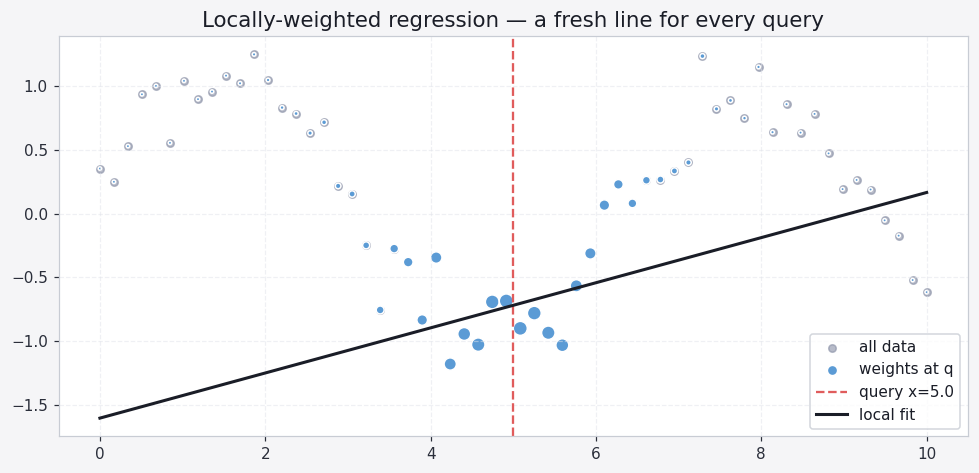

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 60); y = np.sin(x)+0.2*rng.randn(60)
q = 5.0; tau = 1.0
w = np.exp(-(x-q)**2/(2*tau**2))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(x, y, s=24, color=P[6], alpha=0.6, label='all data')
ax.scatter(x, y, s=80*w+5, color=P[0], edgecolor='white', label='weights at q')
ax.axvline(q, color=P[1], ls='--', lw=1.5, label=f'query x={q}')
xx = np.linspace(0, 10, 200)
ww = np.exp(-(x-q)**2/(2*tau**2))
b1, b0 = np.polyfit(x, y, 1, w=ww); ax.plot(xx, b0+b1*xx, color='#1a1d27', lw=2, label='local fit')
ax.set_title('Locally-weighted regression — a fresh line for every query')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(0)
n = 90
x = np.sort(rng.uniform(-3, 3, n))
y = np.sin(2*x) + 0.3*x + rng.normal(0, 0.3, n)
X = np.column_stack([np.ones(n), x])
xs = np.linspace(-3.2, 3.2, 300)

---
## Weighted Normal Equation

For each query $x_q$, build a diagonal weight matrix $W$ with

$$w_i = \exp\!\Bigl(-\frac{(x_i - x_q)^2}{2\tau^2}\Bigr)$$

and solve

$$\theta = (X^T W X)^{-1} X^T W \,\mathbf y, \qquad \hat y(x_q) = [1, x_q]\,\theta.$$

Repeat for every query — LWR is a **memory-based / non-parametric** method. Bandwidth $\tau$ governs how local the fit is.

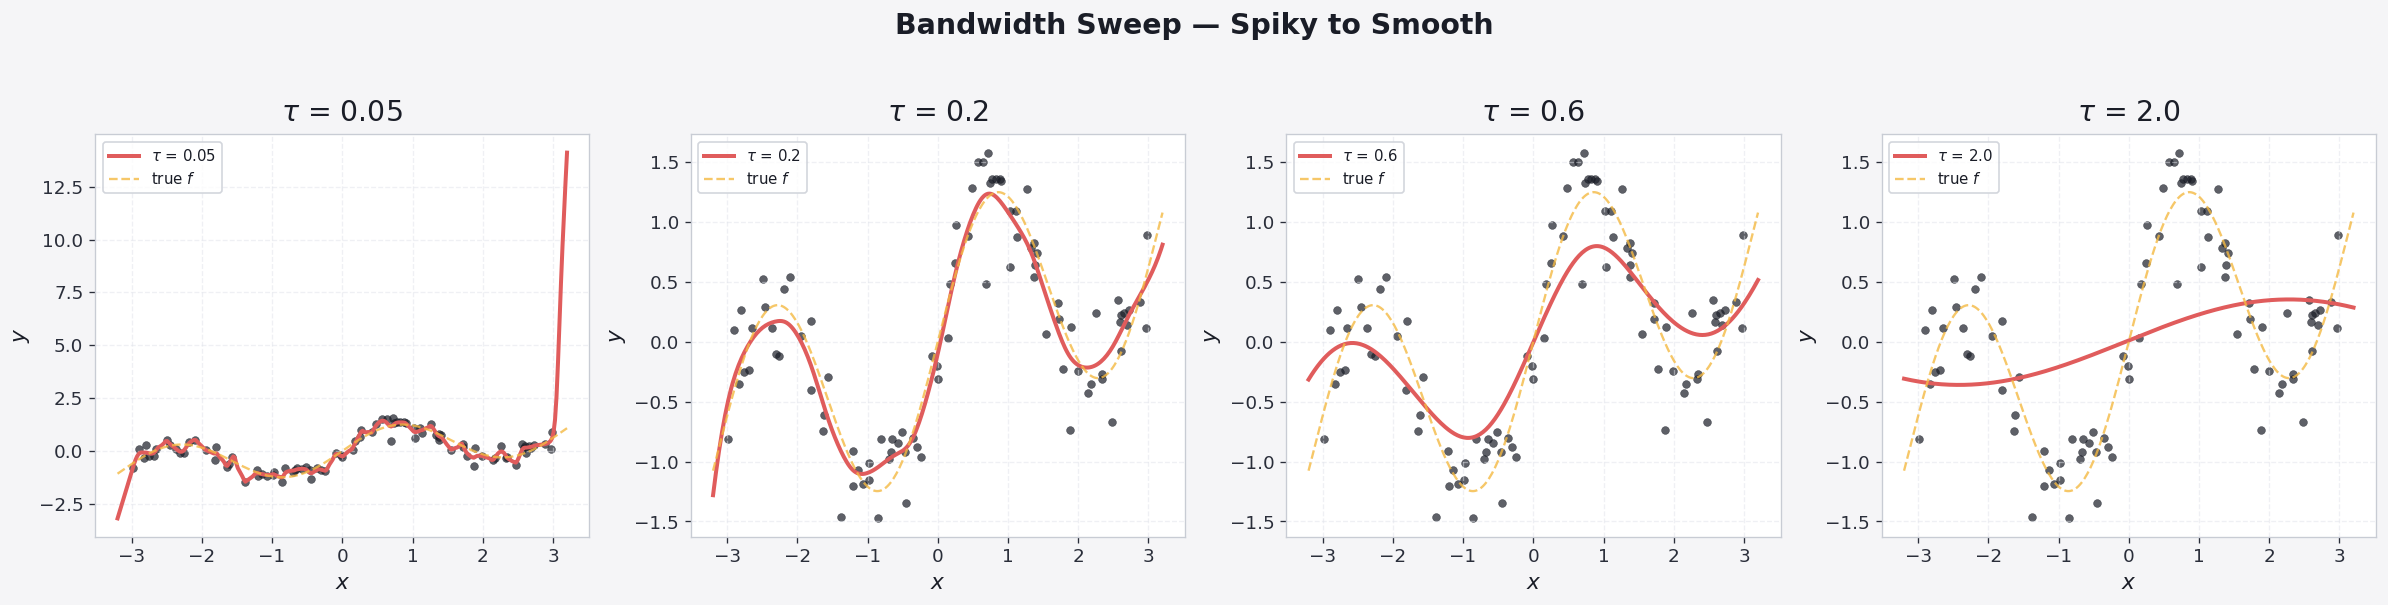

In [3]:
def lwr_predict(x_query, x_train, y_train, tau):
    Xtr = np.column_stack([np.ones(len(x_train)), x_train])
    yhat = np.empty_like(x_query)
    for i, xq in enumerate(x_query):
        w = np.exp(-(x_train - xq)**2 / (2 * tau**2))
        XtW = Xtr.T * w
        theta = np.linalg.solve(XtW @ Xtr, XtW @ y_train)
        yhat[i] = theta[0] + theta[1] * xq
    return yhat

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, tau in zip(axes, [0.05, 0.2, 0.6, 2.0]):
    yhat = lwr_predict(xs, x, y, tau)
    ax.scatter(x, y, c='#1a1d27', s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.7)
    ax.plot(xs, yhat, color=C1, lw=2.4, label=f'$\\tau$ = {tau}')
    ax.plot(xs, np.sin(2*xs) + 0.3*xs, color=CB, lw=1.4, ls='--', alpha=0.8, label='true $f$')
    ax.set_title(f'$\\tau$ = {tau}', pad=8); ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.grid(True); ax.legend(loc='upper left', fontsize=9)
fig.suptitle('Bandwidth Sweep — Spiky to Smooth', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Weights at a Single Query

Pick $x_q = 1.0$ and visualise the bell-shaped weights for several bandwidths. Far points are essentially ignored when $\tau$ is small.

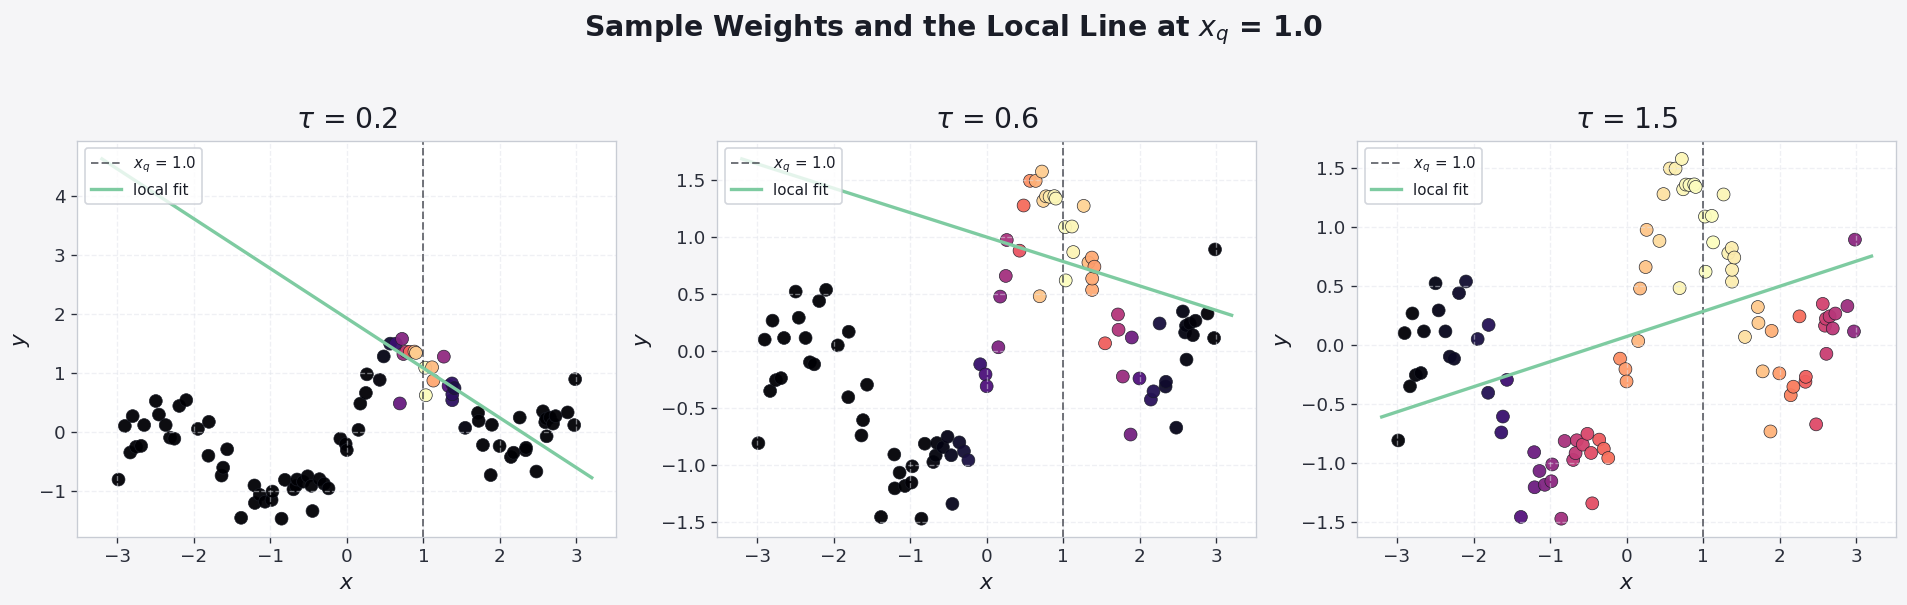

In [4]:
xq = 1.0
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, tau in zip(axes, [0.2, 0.6, 1.5]):
    w = np.exp(-(x - xq)**2 / (2 * tau**2))
    ax.scatter(x, y, c=w, cmap='magma', s=60, edgecolors='#1a1d27', lw=0.4, alpha=0.95)
    ax.axvline(xq, color='#1a1d27', lw=1.2, ls='--', alpha=0.6, label=f'$x_q$ = {xq}')
    Xtr = np.column_stack([np.ones(len(x)), x])
    XtW = Xtr.T * w
    theta = np.linalg.solve(XtW @ Xtr, XtW @ y)
    line = theta[0] + theta[1] * xs
    ax.plot(xs, line, color=CM, lw=2, label='local fit')
    ax.set_title(f'$\\tau$ = {tau}', pad=8); ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.grid(True); ax.legend(loc='upper left', fontsize=9)
fig.suptitle('Sample Weights and the Local Line at $x_q$ = 1.0', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## LWR vs Ordinary Linear Regression

OLS commits to one global line. LWR refits as the query slides, capturing curvature without specifying any basis.

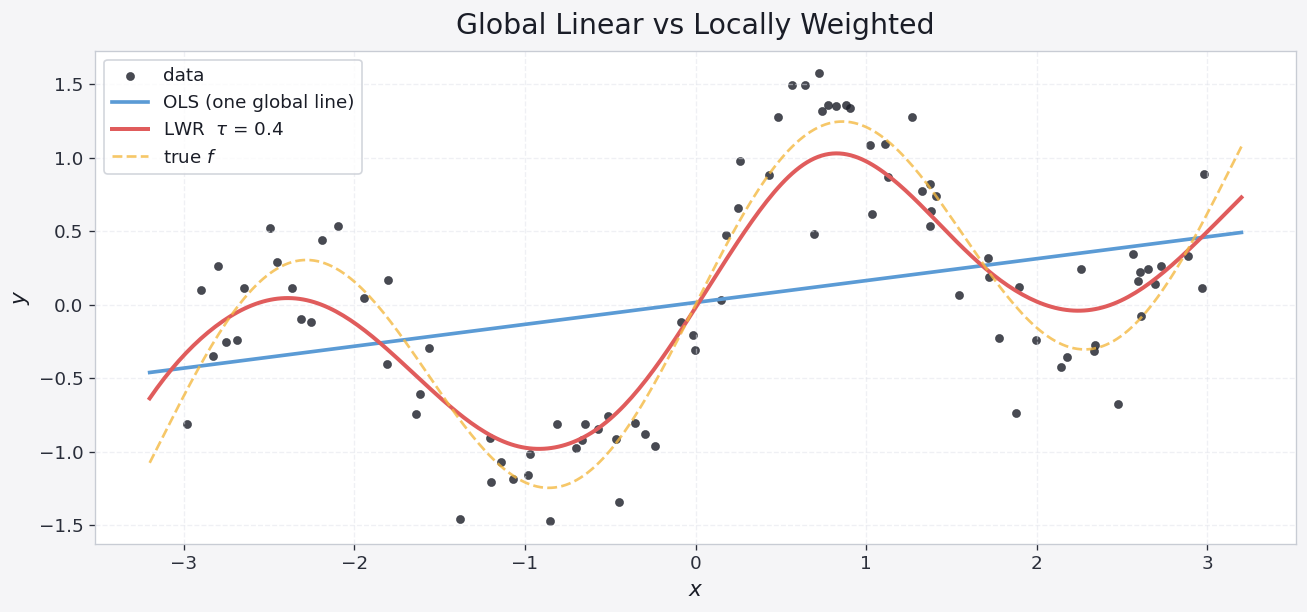

In [5]:
theta_ols = np.linalg.solve(X.T @ X, X.T @ y)
ols_line = theta_ols[0] + theta_ols[1] * xs
yhat_lwr = lwr_predict(xs, x, y, 0.4)

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.scatter(x, y, c='#1a1d27', s=24, edgecolors='#1a1d27', lw=0.3, alpha=0.8, label='data')
ax.plot(xs, ols_line, color=C0, lw=2.2, label='OLS (one global line)')
ax.plot(xs, yhat_lwr, color=C1, lw=2.4, label='LWR  $\\tau$ = 0.4')
ax.plot(xs, np.sin(2*xs) + 0.3*xs, color=CB, lw=1.6, ls='--', alpha=0.8, label='true $f$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Global Linear vs Locally Weighted', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use LWR — and when not to

| Situation | LWR | Polynomial | Splines | Kernel Ridge |
|---|---|---|---|---|
| Smooth nonlinear shape unknown | ✅ adapts locally | ❌ fixed degree | ✅ | ✅ |
| Many features ($d > 5$) | ❌ curse of dimensionality | ✅ | ❌ | ✅ |
| Need predictions in real time | ❌ refits per query | ✅ | ✅ | ✅ |
| Small dataset, low-D | ✅ shines | ❌ overfits | ✅ | ✅ |

> Use LWR when you have **small, low-dimensional** data, you cannot guess the right basis, and you can afford the per-query cost.


---
## 🎯 Try this

1. **Bandwidth on noisy data.** Add more Gaussian noise to $y$ and find the $\tau$ that minimises validation MSE — overshooting toward small $\tau$ should overfit visibly.
2. **Boundary effect.** Predict at $x_q$ near the edges of the training range — fewer neighbours on one side biases the local fit. Compare against the OLS line.
3. **Multivariate.** Extend to 2-D inputs (use $\|x_i - x_q\|$ in the weight). The number of points needed for a good fit grows fast — this is the curse of dimensionality in action.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Local fit | One linear model per query | Adapts shape to data |
| Weights | Gaussian in $|x_i - x_q|$ | Far points discounted |
| Bandwidth $\tau$ | Effective neighbourhood size | Small → wiggly, large → linear |
| Non-parametric | No fixed parameter vector | Must keep all training data |
| Strength | Smooth fits, no basis design | Great for low-D smoothing |
| Weakness | $O(n)$ work per query, no closed form for many queries; chooses $\tau$ by CV | Use kd-tree / KNN cut-off for speed |

**Bottom line:** LWR is the simplest member of the **non-parametric regression** family — fit a line every time you predict, weighted by closeness. The single knob $\tau$ trades flexibility for stability.